In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, classification_report
)

from sklearn.model_selection import LearningCurveDisplay
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_global_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)


In [2]:
DATA_PATH = "heart.csv"  
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

print("\nMissing values per column:")
print(df.isna().sum())

display(df.describe(include="all").T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target   

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [4]:
possible_targets = ["target", "Target", "output", "Output", "label", "Label"]
target_col = next((c for c in possible_targets if c in df.columns), None)

if target_col is None:
    raise ValueError(f"Target column not found. Columns: {list(df.columns)}")

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

print("Target column:", target_col)
print("Class distribution (counts):\n", y.value_counts())
print("\nClass distribution (ratio):\n", y.value_counts(normalize=True))


Target column: target
Class distribution (counts):
 target
1    165
0    138
Name: count, dtype: int64

Class distribution (ratio):
 target
1    0.544554
0    0.455446
Name: proportion, dtype: float64


### preprocessing for senarios

In [5]:
categorical_candidates = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_features = [c for c in categorical_candidates if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

# OneHot dense برای راحتی PCA/TSNE و نمودارها
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# ---- سناریو 1: preprocess برای مدل‌های خطی (impute + scale برای عددی‌ها) ----
numeric_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_linear, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

# ---- سناریو 2: preprocess برای مدل‌های درختی (impute بدون scale) ----
numeric_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_tree, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

# ---- سناریو 3 (اختیاری برای تحلیل): tree + scaler (فقط برای مقایسه اثر scaler روی RF) ----
preprocess_tree_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_linear, numeric_features),  # همان مسیر linear یعنی impute+scale
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)


Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


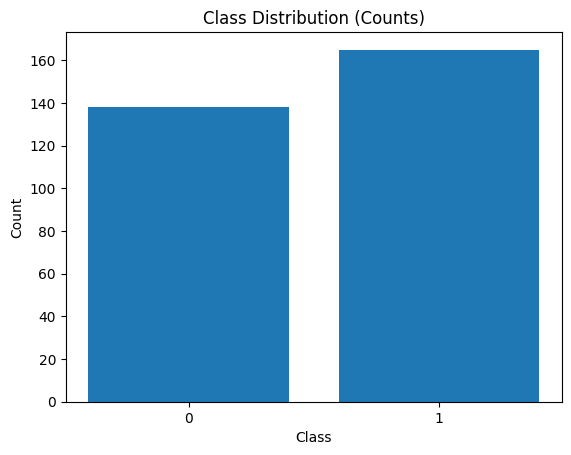

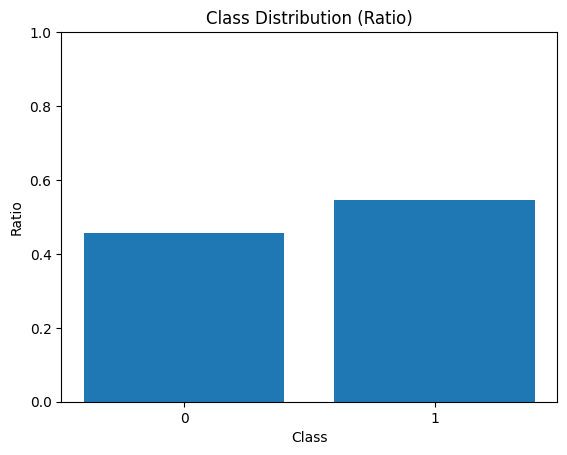

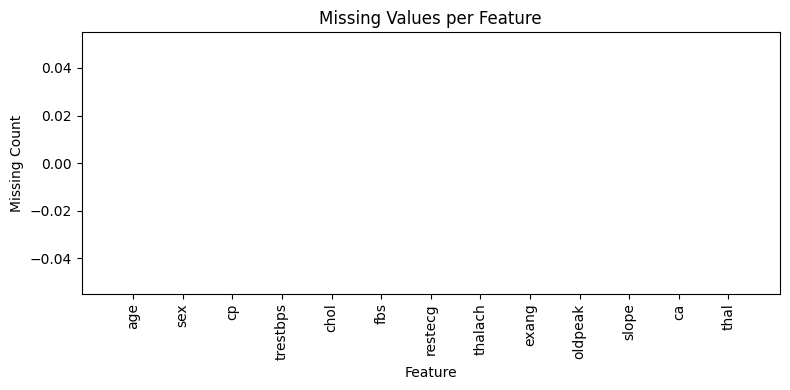

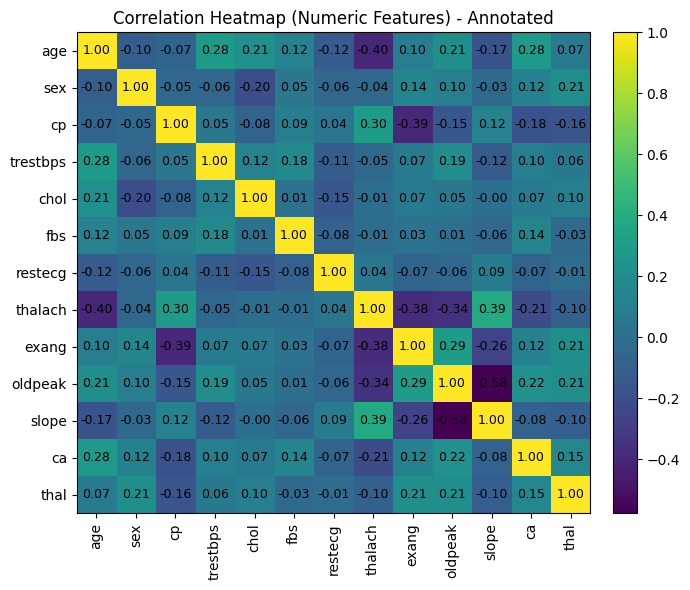

In [6]:

# 1) Class distribution (counts + ratio)
counts = y.value_counts().sort_index()
ratios = y.value_counts(normalize=True).sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (Counts)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.bar(ratios.index.astype(str), ratios.values)
plt.title("Class Distribution (Ratio)")
plt.xlabel("Class")
plt.ylabel("Ratio")
plt.ylim(0, 1)
plt.show()

# 2) Missing values per feature
miss = X.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(miss.index.astype(str), miss.values)
plt.title("Missing Values per Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 3) Correlation heatmap (numeric only) + write corr values inside cells
# Make this cell independent from later cells:
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()

num_df = X[numeric_features].copy()
corr = num_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, aspect="auto")

ax.set_title("Correlation Heatmap (Numeric Features) - Annotated")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)

# Add a colorbar
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Annotate each cell with the correlation value
# (pattern based on Matplotlib's annotated heatmap example)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center", va="center",
            fontsize=9,
            color="black"
        )

plt.tight_layout()
plt.show()


### Train/val/test

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (212, 13) Val: (45, 13) Test: (46, 13)


### metric func

In [8]:
def compute_metrics(estimator, X_, y_):
    y_pred = estimator.predict(X_)
    out = {
        "acc": accuracy_score(y_, y_pred),
        "precision": precision_score(y_, y_pred, zero_division=0),
        "recall": recall_score(y_, y_pred, zero_division=0),
        "f1": f1_score(y_, y_pred, zero_division=0),
    }
    if hasattr(estimator, "predict_proba"):
        y_proba = estimator.predict_proba(X_)[:, 1]
        out["roc_auc"] = roc_auc_score(y_, y_proba)
        out["pr_auc"] = average_precision_score(y_, y_proba)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan
    return out

def make_train_val_test_table(fitted_models: dict, tag: str):
    rows = []
    for name, mdl in fitted_models.items():
        tr = compute_metrics(mdl, X_train, y_train)
        va = compute_metrics(mdl, X_val, y_val)
        te = compute_metrics(mdl, X_test, y_test)
        rows.append({
            "group": tag,
            "model": name,
            "train_f1": tr["f1"], "val_f1": va["f1"], "test_f1": te["f1"],
            "train_acc": tr["acc"], "val_acc": va["acc"], "test_acc": te["acc"],
            "train_auc": tr["roc_auc"], "val_auc": va["roc_auc"], "test_auc": te["roc_auc"],
            "train_pr_auc": tr["pr_auc"], "val_pr_auc": va["pr_auc"], "test_pr_auc": te["pr_auc"],
            "overfit_gap_f1 (train-val)": tr["f1"] - va["f1"],
        })
    return pd.DataFrame(rows)


### PCA + t-SNE (Visualization & Analysis)

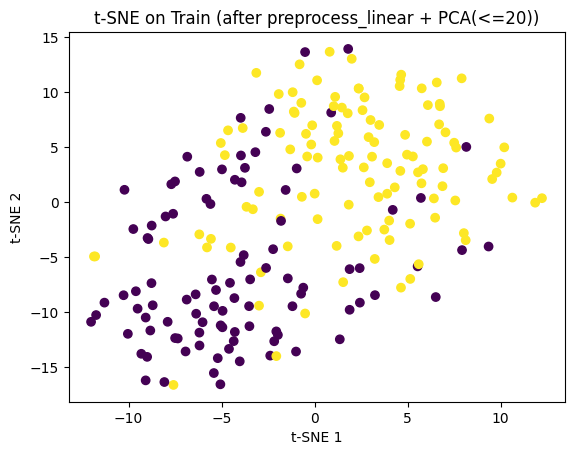

In [9]:
X_train_trans = preprocess_linear.fit_transform(X_train)
y_train_np = np.array(y_train)

# PCA برای نمایش/کاهش نویز قبل از t-SNE
pca_vis = PCA(n_components=min(20, X_train_trans.shape[1]), random_state=RANDOM_STATE)
X_pca_vis = pca_vis.fit_transform(X_train_trans)

# t-SNE برای 2D visualization
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca_vis)

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train_np)
plt.title("t-SNE on Train (after preprocess_linear + PCA(<=20))")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


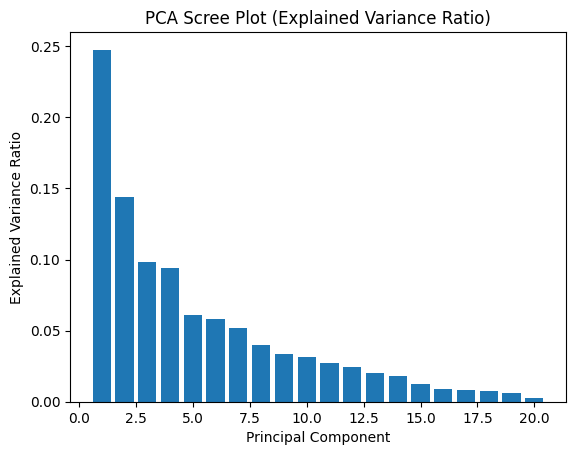

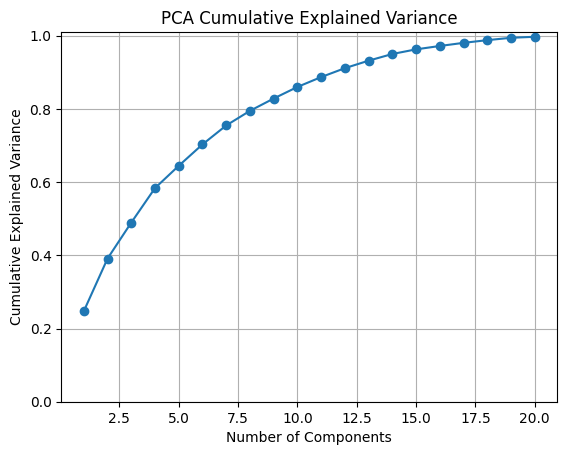

Components needed for >=95% variance (within pca_vis): 14


In [10]:
# =========================
# PCA Explained Variance (Scree + Cumulative)
# =========================

evr = pca_vis.explained_variance_ratio_
cum = np.cumsum(evr)

plt.figure()
plt.bar(range(1, len(evr) + 1), evr)
plt.title("PCA Scree Plot (Explained Variance Ratio)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

plt.figure()
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.ylim(0, 1.01)
plt.grid(True)
plt.show()

# Optional: report how many comps reach 0.95
k95 = int(np.argmax(cum >= 0.95) + 1) if np.any(cum >= 0.95) else None
print("Components needed for >=95% variance (within pca_vis):", k95)


### تعریف مدل‌های پایه (Untuned) + نسخه‌های PCA + سناریوی RF با/بدون Scaler

In [11]:
# Logistic Regression 
logreg = Pipeline(steps=[
    ("prep", preprocess_linear),
    ("clf", LogisticRegression(max_iter=7000, random_state=RANDOM_STATE))
])

logreg_pca = Pipeline(steps=[
    ("prep", preprocess_linear),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=7000, random_state=RANDOM_STATE))
])

#  Random Forest 
rf = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", RandomForestClassifier(
        n_estimators=900,
        random_state=RANDOM_STATE,
        bootstrap=True,
        max_samples=0.7,
        max_features="sqrt",
        max_depth=6,
        min_samples_split=12,
        min_samples_leaf=6,
        ccp_alpha=0.001,
        class_weight="balanced"
    ))
])

# RF با scaler فقط برای مقایسه اثر preprocessing
rf_scaled = Pipeline(steps=[
    ("prep", preprocess_tree_scaled),
    ("clf", RandomForestClassifier(
        n_estimators=900,
        random_state=RANDOM_STATE,
        bootstrap=True,
        max_samples=0.7,
        max_features="sqrt",
        max_depth=6,
        min_samples_split=12,
        min_samples_leaf=6,
        ccp_alpha=0.001,
        class_weight="balanced"
    ))
])

# RF + PCA صرفاً برای مقایسه اثر PCA
rf_pca = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(
        n_estimators=900,
        random_state=RANDOM_STATE,
        bootstrap=True,
        max_samples=0.7,
        max_features="sqrt",
        max_depth=6,
        min_samples_split=12,
        min_samples_leaf=6,
        ccp_alpha=0.001,
        class_weight="balanced"
    ))
])

# AdaBoost (Boosting)
ada = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=300,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ))
])

ada_pca = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        n_estimators=300,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ))
])

untuned_models = {
    "LogReg": logreg,
    "LogReg+PCA": logreg_pca,
    "RF": rf,
    "RF (scaled preprocess)": rf_scaled,
    "RF+PCA": rf_pca,
    "AdaBoost": ada,
    "AdaBoost+PCA": ada_pca
}


In [12]:
fitted_untuned = {}
for name, mdl in untuned_models.items():
    mdl.fit(X_train, y_train)
    fitted_untuned[name] = mdl

tbl_untuned = make_train_val_test_table(fitted_untuned, tag="untuned")
tbl_untuned.sort_values("val_f1", ascending=False).reset_index(drop=True)


,group,model,train_f1,val_f1,test_f1,train_acc,val_acc,test_acc,train_auc,val_auc,test_auc,train_pr_auc,val_pr_auc,test_pr_auc,overfit_gap_f1 (train-val)
0,untuned,LogReg+PCA,0.901288,0.833333,0.800000,0.891509,0.822222,0.782609,0.945675,0.894,0.864762,0.952522,0.917308,0.889591,0.067954
1,untuned,RF,0.904348,0.823529,0.792453,0.896226,0.800000,0.760870,0.962438,0.894,0.866667,0.966667,0.919669,0.895261,0.080818
2,untuned,RF (scaled preprocess),0.904348,0.823529,0.792453,0.896226,0.800000,0.760870,0.962438,0.894,0.866667,0.966591,0.919669,0.895261,0.080818
3,untuned,LogReg,0.897436,0.816327,0.807692,0.886792,0.800000,0.782609,0.948723,0.894,0.872381,0.952956,0.915503,0.899852,0.081109
4,untuned,AdaBoost,0.927039,0.816327,0.784314,0.919811,0.800000,0.760870,0.980816,0.898,0.836190,0.984695,0.922635,0.868644,0.110712
5,untuned,RF+PCA,0.766520,0.807692,0.692308,0.750000,0.777778,0.652174,0.869924,0.732,0.744762,0.893531,0.722828,0.800356,-0.041172
6,untuned,AdaBoost+PCA,0.767241,0.800000,0.627451,0.745283,0.755556,0.586957,0.819677,0.791,0.688571,0.836640,0.804562,0.765156,-0.032759


### Cross-Validation

In [13]:
scoring = {
    "acc": "accuracy",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

def cv_table(model_dict, tag):
    rows = []
    for name, mdl in model_dict.items():
        out = cross_validate(mdl, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
        rows.append({
            "group": tag,
            "model": name,
            "cv_f1_mean": np.mean(out["test_f1"]), "cv_f1_std": np.std(out["test_f1"]),
            "cv_acc_mean": np.mean(out["test_acc"]), "cv_acc_std": np.std(out["test_acc"]),
            "cv_auc_mean": np.mean(out["test_roc_auc"]), "cv_auc_std": np.std(out["test_roc_auc"]),
            "cv_pr_auc_mean": np.mean(out["test_pr_auc"]), "cv_pr_auc_std": np.std(out["test_pr_auc"]),
        })
    return pd.DataFrame(rows)

cv_untuned = cv_table(untuned_models, tag="untuned")
cv_untuned.sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)


,group,model,cv_f1_mean,cv_f1_std,cv_acc_mean,cv_acc_std,cv_auc_mean,cv_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,untuned,LogReg,0.869236,0.042760,0.853377,0.049471,0.918536,0.034853,0.924842,0.039445
1,untuned,LogReg+PCA,0.868574,0.040577,0.854077,0.046661,0.919205,0.031393,0.925849,0.035368
2,untuned,AdaBoost,0.845988,0.042972,0.828295,0.048065,0.893096,0.032420,0.902040,0.039443
3,untuned,RF,0.839003,0.045548,0.825016,0.049943,0.916025,0.031273,0.927111,0.030098
4,untuned,RF (scaled preprocess),0.839003,0.045548,0.825016,0.049943,0.916466,0.031116,0.927448,0.029958
5,untuned,AdaBoost+PCA,0.698009,0.049124,0.666590,0.049078,0.716092,0.056837,0.742445,0.059263
6,untuned,RF+PCA,0.688886,0.047836,0.665902,0.048518,0.724905,0.048793,0.755374,0.049177


### نمودارهای پایه (Untuned): Confusion + ROC + PR

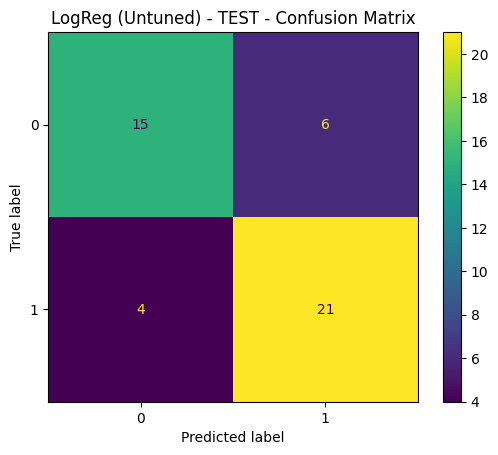

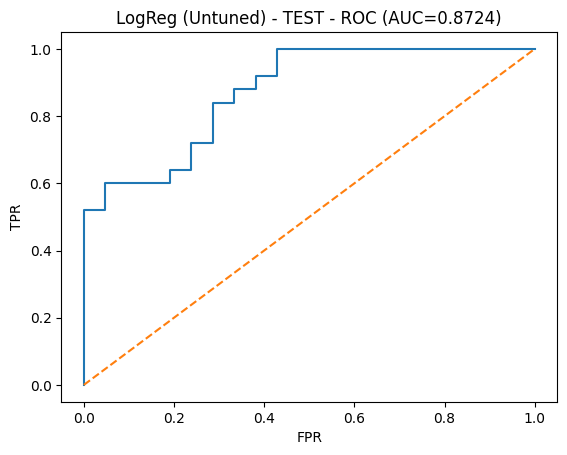

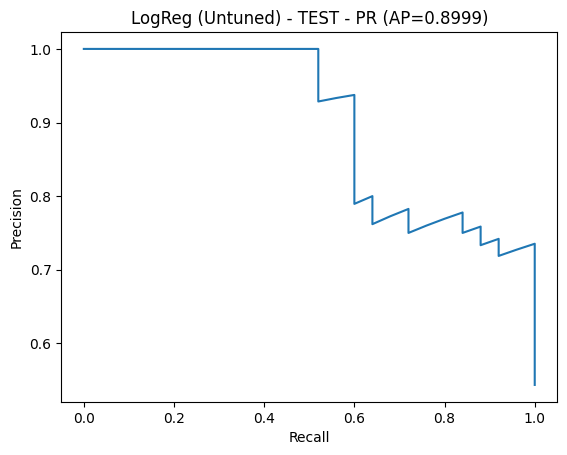

In [14]:
def plot_diagnostics(model, X_eval, y_eval, title="Model"):
    # Confusion
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_eval, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{title} - Confusion Matrix")
    plt.show()

    # ROC/PR if proba exists
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]

        fpr, tpr, _ = roc_curve(y_eval, proba)
        auc_ = roc_auc_score(y_eval, proba)
        plt.figure()
        plt.plot(fpr, tpr)
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.title(f"{title} - ROC (AUC={auc_:.4f})")
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.show()

        prec, rec, _ = precision_recall_curve(y_eval, proba)
        ap = average_precision_score(y_eval, proba)
        plt.figure()
        plt.plot(rec, prec)
        plt.title(f"{title} - PR (AP={ap:.4f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.show()

# یک مثال: بهترین مدل untuned بر اساس CV-F1
best_untuned_name = cv_untuned.sort_values("cv_f1_mean", ascending=False).iloc[0]["model"]
plot_diagnostics(fitted_untuned[best_untuned_name], X_test, y_test, title=f"{best_untuned_name} (Untuned) - TEST")


### Hyperparameter Tuning (Grid/Random Search)

#### LogReg+PCA (Tuned) gridsearch

In [15]:
cv_simple = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_logreg_pca = Pipeline(steps=[
    ("prep", preprocess_linear),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=8000, random_state=RANDOM_STATE))
])

param_grid_logreg = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__solver": ["lbfgs"],
    "clf__penalty": ["l2"]
}

grid_logreg = GridSearchCV(
    pipe_logreg_pca,
    param_grid=param_grid_logreg,
    scoring="f1",
    cv=cv_simple,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_logreg.fit(X_train, y_train)

print("Best params (LogReg+PCA):", grid_logreg.best_params_)
print("Best CV F1:", grid_logreg.best_score_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params (LogReg+PCA): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'pca__n_components': 0.99}
Best CV F1: 0.8785889464965686


#### RF (Tuned) RandomizedSearch

In [16]:
from scipy.stats import randint, uniform

pipe_rf = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        bootstrap=True
    ))
])

param_dist_rf = {
    "clf__n_estimators": randint(400, 1500),
    "clf__max_depth": randint(3, 14),
    "clf__min_samples_split": randint(6, 30),
    "clf__min_samples_leaf": randint(2, 15),
    "clf__max_features": ["sqrt", "log2", None],
    "clf__max_samples": uniform(0.4, 0.6),     # 0.4 تا 1.0 (تقریباً)
    "clf__ccp_alpha": uniform(0.0, 0.01)       # pruning
}

rs_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=50,
    scoring="f1",
    cv=cv_simple,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=True
)
rs_rf.fit(X_train, y_train)

print("Best params (RF):", rs_rf.best_params_)
print("Best CV F1:", rs_rf.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params (RF): {'clf__ccp_alpha': np.float64(0.0004043358953843135), 'clf__max_depth': 12, 'clf__max_features': 'log2', 'clf__max_samples': np.float64(0.663601901119462), 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 12, 'clf__n_estimators': 963}
Best CV F1: 0.8809398331137462


#### AdaBoost (Tuned) gridsearch

In [17]:
pipe_ada = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("clf", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE
    ))
])

param_grid_ada = {
    "clf__estimator__max_depth": [1, 2, 3],
    "clf__n_estimators": [50, 100, 200, 400],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    pipe_ada,
    param_grid=param_grid_ada,
    scoring="f1",
    cv=cv_simple,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_ada.fit(X_train, y_train)

print("Best params (AdaBoost):", grid_ada.best_params_)
print("Best CV F1:", grid_ada.best_score_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params (AdaBoost): {'clf__estimator__max_depth': 1, 'clf__learning_rate': 0.05, 'clf__n_estimators': 100}
Best CV F1: 0.8744036930220747


#### گزارش “تمام پارامترهای جستجو شده”

In [18]:
def cv_results_to_df(search_obj, top_k=15, sort_by="rank_test_score"):
    df_res = pd.DataFrame(search_obj.cv_results_)
    if sort_by in df_res.columns:
        df_res = df_res.sort_values(sort_by, ascending=True)
    return df_res.head(top_k)

logreg_search_results = cv_results_to_df(grid_logreg, top_k=20, sort_by="rank_test_score")
rf_search_results     = cv_results_to_df(rs_rf, top_k=20, sort_by="rank_test_score")
ada_search_results    = cv_results_to_df(grid_ada, top_k=20, sort_by="rank_test_score")

print("Top 20 - LogReg+PCA GridSearch results:")
display(logreg_search_results)

print("Top 20 - RF RandomizedSearch results:")
display(rf_search_results)

print("Top 20 - AdaBoost GridSearch results:")
display(ada_search_results)


Top 20 - LogReg+PCA GridSearch results:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__C,param_clf__penalty,param_clf__solver,param_pca__n_components,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
5,0.123144,0.006480,0.074256,0.001740,0.10,l2,lbfgs,0.99,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.833333,0.869565,0.837209,0.936170,0.916667,0.878589,0.041490,1,0.908108,0.894737,0.900524,0.899471,0.882979,0.897164,0.008288
3,0.096181,0.010447,0.072538,0.005104,0.10,l2,lbfgs,0.90,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.808511,0.869565,0.837209,0.936170,0.916667,0.873624,0.047638,2,0.902174,0.870968,0.888889,0.887701,0.877005,0.885347,0.010748
4,0.128031,0.003780,0.078506,0.005456,0.10,l2,lbfgs,0.95,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.782609,0.869565,0.837209,0.936170,0.916667,0.868444,0.055239,3,0.902174,0.878307,0.888889,0.892473,0.877005,0.887770,0.009341
6,0.137790,0.004635,0.079573,0.006568,1.00,l2,lbfgs,0.90,"{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solv...",0.823529,0.869565,0.837209,0.888889,0.916667,0.867172,0.033851,4,0.895028,0.882979,0.893617,0.891304,0.874317,0.887449,0.007782
8,0.141836,0.010547,0.095795,0.004819,1.00,l2,lbfgs,0.99,"{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solv...",0.816327,0.869565,0.863636,0.913043,0.869565,0.866427,0.030694,5,0.929730,0.888889,0.910053,0.898396,0.898396,0.905093,0.014027
7,0.152503,0.007902,0.090733,0.005359,1.00,l2,lbfgs,0.95,"{'clf__C': 1, 'clf__penalty': 'l2', 'clf__solv...",0.791667,0.869565,0.837209,0.913043,0.916667,0.865630,0.047216,6,0.923913,0.888889,0.905263,0.903226,0.892473,0.902753,0.012265
9,0.163038,0.018751,0.091691,0.010367,10.00,l2,lbfgs,0.90,"{'clf__C': 10, 'clf__penalty': 'l2', 'clf__sol...",0.800000,0.869565,0.837209,0.888889,0.916667,0.862466,0.040562,7,0.895028,0.882979,0.881720,0.880435,0.886486,0.885330,0.005252
12,0.157399,0.009468,0.070059,0.011390,100.00,l2,lbfgs,0.90,"{'clf__C': 100, 'clf__penalty': 'l2', 'clf__so...",0.800000,0.869565,0.837209,0.888889,0.916667,0.862466,0.040562,7,0.901099,0.882979,0.886486,0.880435,0.886486,0.887497,0.007174
13,0.120575,0.010790,0.051181,0.001923,100.00,l2,lbfgs,0.95,"{'clf__C': 100, 'clf__penalty': 'l2', 'clf__so...",0.755556,0.869565,0.837209,0.913043,0.916667,0.858408,0.059214,9,0.918033,0.887701,0.898396,0.892473,0.893617,0.898044,0.010557
10,0.173924,0.013502,0.079189,0.004280,10.00,l2,lbfgs,0.95,"{'clf__C': 10, 'clf__penalty': 'l2', 'clf__sol...",0.755556,0.869565,0.837209,0.913043,0.916667,0.858408,0.059214,9,0.918033,0.887701,0.898396,0.892473,0.893617,0.898044,0.010557


Top 20 - RF RandomizedSearch results:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__ccp_alpha,param_clf__max_depth,param_clf__max_features,param_clf__max_samples,param_clf__min_samples_leaf,param_clf__min_samples_split,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
17,9.582563,0.077895,0.550848,0.023696,0.000404,12,log2,0.663602,4,12,963,"{'clf__ccp_alpha': 0.0004043358953843135, 'clf...",0.826087,0.888889,0.863636,0.913043,0.913043,0.880940,0.032963,1,0.924731,0.908108,0.917127,0.897297,0.912088,0.911870,0.009161
15,10.240111,0.071234,0.558297,0.011283,0.007296,10,log2,0.932328,2,8,1012,"{'clf__ccp_alpha': 0.007296061783380641, 'clf_...",0.826087,0.888889,0.863636,0.888889,0.913043,0.876109,0.029491,2,0.940541,0.919786,0.946237,0.936170,0.940541,0.936655,0.009020
44,13.264416,0.112181,0.721938,0.008715,0.006960,10,log2,0.458306,7,28,1361,"{'clf__ccp_alpha': 0.0069602979667497305, 'clf...",0.818182,0.888889,0.863636,0.888889,0.913043,0.874528,0.032216,3,0.901099,0.883978,0.888889,0.853933,0.865169,0.878613,0.016911
41,4.972860,0.042192,0.307612,0.005499,0.007686,3,log2,0.972357,6,11,498,"{'clf__ccp_alpha': 0.00768554014306309, 'clf__...",0.800000,0.888889,0.863636,0.893617,0.913043,0.871837,0.039220,4,0.907104,0.897297,0.912088,0.897297,0.906077,0.903973,0.005817
35,9.673243,0.099735,0.568090,0.010608,0.009356,6,log2,0.801393,4,21,909,"{'clf__ccp_alpha': 0.009356349942209475, 'clf_...",0.818182,0.888889,0.863636,0.863636,0.913043,0.869477,0.031541,5,0.901099,0.908108,0.917127,0.897297,0.888889,0.902504,0.009588
34,9.833170,0.088295,0.584523,0.045051,0.008467,6,log2,0.867925,9,25,986,"{'clf__ccp_alpha': 0.00846661142238306, 'clf__...",0.790698,0.888889,0.863636,0.888889,0.913043,0.869031,0.042169,6,0.895028,0.879121,0.905028,0.872928,0.871508,0.884723,0.013142
10,6.325710,0.089616,0.392749,0.007848,0.009612,7,sqrt,0.562809,6,29,616,"{'clf__ccp_alpha': 0.009611720243493492, 'clf_...",0.790698,0.888889,0.863636,0.888889,0.913043,0.869031,0.042169,6,0.895028,0.885246,0.886364,0.866667,0.870056,0.880672,0.010661
39,11.890839,0.201235,0.644352,0.015434,0.009789,5,log2,0.943659,12,7,1197,"{'clf__ccp_alpha': 0.00978892858275009, 'clf__...",0.790698,0.888889,0.863636,0.888889,0.913043,0.869031,0.042169,6,0.895028,0.885246,0.905028,0.879121,0.871508,0.887186,0.011785
32,12.940184,0.037778,0.694740,0.007181,0.006600,12,sqrt,0.709982,2,7,1296,"{'clf__ccp_alpha': 0.006599840460341791, 'clf_...",0.782609,0.888889,0.863636,0.869565,0.936170,0.868174,0.049793,9,0.934783,0.919786,0.946237,0.936170,0.940541,0.935503,0.008816
40,9.313801,0.018843,0.518932,0.012080,0.006451,3,sqrt,0.538111,4,9,946,"{'clf__ccp_alpha': 0.006451033620305649, 'clf_...",0.782609,0.888889,0.863636,0.888889,0.913043,0.867413,0.045190,10,0.913043,0.908108,0.917127,0.897297,0.902174,0.907550,0.007159


Top 20 - AdaBoost GridSearch results:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clf__estimator__max_depth,param_clf__learning_rate,param_clf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
5,1.289170,0.014236,0.211469,0.005014,1,0.05,100,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.826087,0.823529,0.869565,0.936170,0.916667,0.874404,0.045929,1,0.924731,0.881720,0.880829,0.887701,0.877005,0.890397,0.017506
26,2.715472,0.023649,0.355372,0.017352,2,0.05,200,"{'clf__estimator__max_depth': 2, 'clf__learnin...",0.857143,0.840000,0.837209,0.916667,0.916667,0.873537,0.035871,2,0.935484,0.909091,0.927083,0.921466,0.925532,0.923731,0.008626
3,5.013882,0.022725,0.648737,0.014964,1,0.01,400,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.808511,0.823529,0.893617,0.936170,0.893617,0.871089,0.047809,3,0.924731,0.881720,0.876289,0.892473,0.872340,0.889511,0.018866
10,2.504165,0.012389,0.372118,0.009594,1,0.10,200,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.816327,0.823529,0.863636,0.916667,0.916667,0.867365,0.043363,4,0.924731,0.882979,0.900524,0.887701,0.881720,0.895531,0.016045
4,0.712208,0.044454,0.135752,0.006113,1,0.05,50,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.808511,0.823529,0.893617,0.897959,0.913043,0.867332,0.042655,5,0.919786,0.882979,0.864583,0.885417,0.870968,0.884747,0.019119
12,0.753315,0.025847,0.142489,0.009454,1,0.50,50,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.791667,0.840000,0.863636,0.916667,0.916667,0.865727,0.047625,6,0.930481,0.892473,0.907216,0.904255,0.887701,0.904425,0.014895
9,1.363470,0.013973,0.213787,0.004437,1,0.10,100,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.816327,0.823529,0.844444,0.897959,0.936170,0.863686,0.046161,7,0.924731,0.882979,0.895833,0.893617,0.877005,0.894833,0.016460
8,0.734288,0.018852,0.147772,0.007618,1,0.10,50,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.808511,0.823529,0.869565,0.897959,0.916667,0.863246,0.041646,8,0.924731,0.877005,0.887755,0.899471,0.872340,0.892261,0.018741
7,4.977174,0.006948,0.636477,0.009582,1,0.05,400,"{'clf__estimator__max_depth': 1, 'clf__learnin...",0.816327,0.823529,0.837209,0.916667,0.916667,0.862080,0.045072,9,0.924731,0.882979,0.895833,0.898396,0.881720,0.896732,0.015505
29,1.587870,0.021753,0.218643,0.005954,2,0.10,100,"{'clf__estimator__max_depth': 2, 'clf__learnin...",0.816327,0.823529,0.829268,0.916667,0.916667,0.860492,0.046050,10,0.952381,0.914894,0.931937,0.926316,0.926316,0.930369,0.012323


### Tuned vs Untuned

In [19]:
tuned_models = {
    "LogReg+PCA (Tuned)": grid_logreg.best_estimator_,
    "RF (Tuned)": rs_rf.best_estimator_,
    "AdaBoost (Tuned)": grid_ada.best_estimator_
}

fitted_tuned = {}
for name, mdl in tuned_models.items():
    mdl.fit(X_train, y_train)
    fitted_tuned[name] = mdl


#### جدول مقایسه متریک‌ها (Train/Val/Test) برای tuned و untuned

In [20]:
tbl_tuned = make_train_val_test_table(fitted_tuned, tag="tuned")

compare_train_val_test = pd.concat([tbl_untuned, tbl_tuned], ignore_index=True)
compare_train_val_test.sort_values(["group", "val_f1"], ascending=[True, False]).reset_index(drop=True)


,group,model,train_f1,val_f1,test_f1,train_acc,val_acc,test_acc,train_auc,val_auc,test_auc,train_pr_auc,val_pr_auc,test_pr_auc,overfit_gap_f1 (train-val)
0,tuned,LogReg+PCA (Tuned),0.898305,0.823529,0.807692,0.886792,0.800000,0.782609,0.942537,0.900,0.876190,0.948461,0.924278,0.902491,0.074776
1,tuned,AdaBoost (Tuned),0.885106,0.814815,0.836364,0.872642,0.777778,0.804348,0.941013,0.872,0.825714,0.940485,0.896519,0.855188,0.070292
2,tuned,RF (Tuned),0.905172,0.807692,0.807692,0.896226,0.777778,0.782609,0.964231,0.894,0.855238,0.968895,0.919669,0.881488,0.097480
3,untuned,LogReg+PCA,0.901288,0.833333,0.800000,0.891509,0.822222,0.782609,0.945675,0.894,0.864762,0.952522,0.917308,0.889591,0.067954
4,untuned,RF,0.904348,0.823529,0.792453,0.896226,0.800000,0.760870,0.962438,0.894,0.866667,0.966667,0.919669,0.895261,0.080818
5,untuned,RF (scaled preprocess),0.904348,0.823529,0.792453,0.896226,0.800000,0.760870,0.962438,0.894,0.866667,0.966591,0.919669,0.895261,0.080818
6,untuned,LogReg,0.897436,0.816327,0.807692,0.886792,0.800000,0.782609,0.948723,0.894,0.872381,0.952956,0.915503,0.899852,0.081109
7,untuned,AdaBoost,0.927039,0.816327,0.784314,0.919811,0.800000,0.760870,0.980816,0.898,0.836190,0.984695,0.922635,0.868644,0.110712
8,untuned,RF+PCA,0.766520,0.807692,0.692308,0.750000,0.777778,0.652174,0.869924,0.732,0.744762,0.893531,0.722828,0.800356,-0.041172
9,untuned,AdaBoost+PCA,0.767241,0.800000,0.627451,0.745283,0.755556,0.586957,0.819677,0.791,0.688571,0.836640,0.804562,0.765156,-0.032759


#### tuned + مقایسه با untuned

In [21]:
cv_tuned = cv_table(tuned_models, tag="tuned")

cv_compare = pd.concat([cv_untuned, cv_tuned], ignore_index=True)
cv_compare.sort_values(["group", "cv_f1_mean"], ascending=[True, False]).reset_index(drop=True)


,group,model,cv_f1_mean,cv_f1_std,cv_acc_mean,cv_acc_std,cv_auc_mean,cv_auc_std,cv_pr_auc_mean,cv_pr_auc_std
0,tuned,LogReg+PCA (Tuned),0.867484,0.039313,0.851399,0.045663,0.919147,0.032441,0.927596,0.034611
1,tuned,AdaBoost (Tuned),0.852319,0.035200,0.829628,0.043676,0.901052,0.037308,0.905953,0.042912
2,tuned,RF (Tuned),0.839410,0.046035,0.825661,0.050698,0.916251,0.030907,0.928050,0.029013
3,untuned,LogReg,0.869236,0.042760,0.853377,0.049471,0.918536,0.034853,0.924842,0.039445
4,untuned,LogReg+PCA,0.868574,0.040577,0.854077,0.046661,0.919205,0.031393,0.925849,0.035368
5,untuned,AdaBoost,0.845988,0.042972,0.828295,0.048065,0.893096,0.032420,0.902040,0.039443
6,untuned,RF,0.839003,0.045548,0.825016,0.049943,0.916025,0.031273,0.927111,0.030098
7,untuned,RF (scaled preprocess),0.839003,0.045548,0.825016,0.049943,0.916466,0.031116,0.927448,0.029958
8,untuned,AdaBoost+PCA,0.698009,0.049124,0.666590,0.049078,0.716092,0.056837,0.742445,0.059263
9,untuned,RF+PCA,0.688886,0.047836,0.665902,0.048518,0.724905,0.048793,0.755374,0.049177


#### tuned (Confusion + ROC + PR)

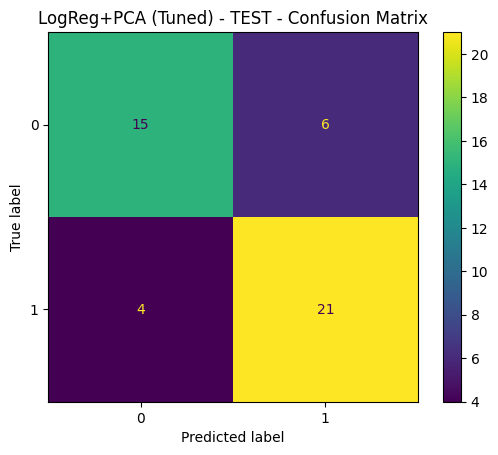

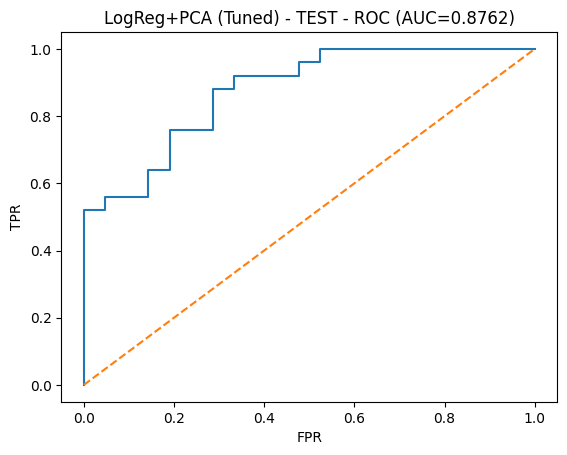

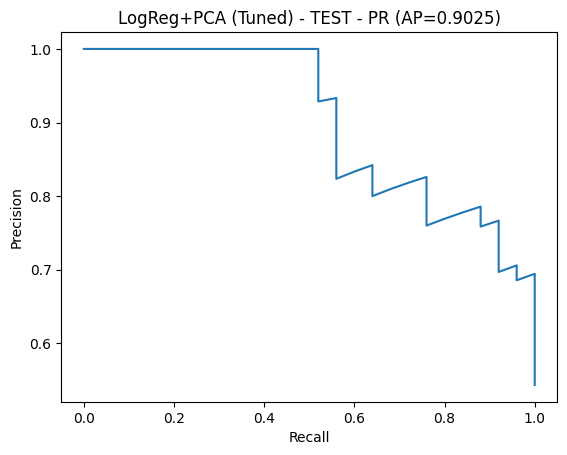

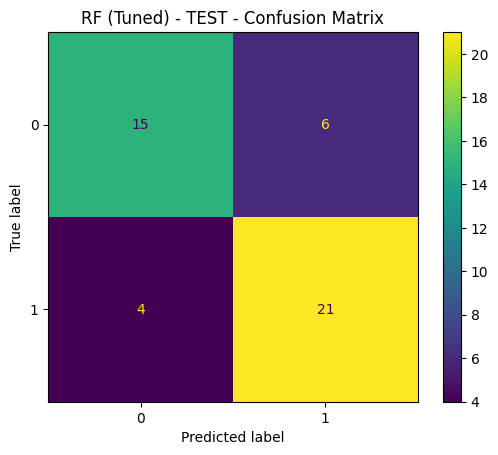

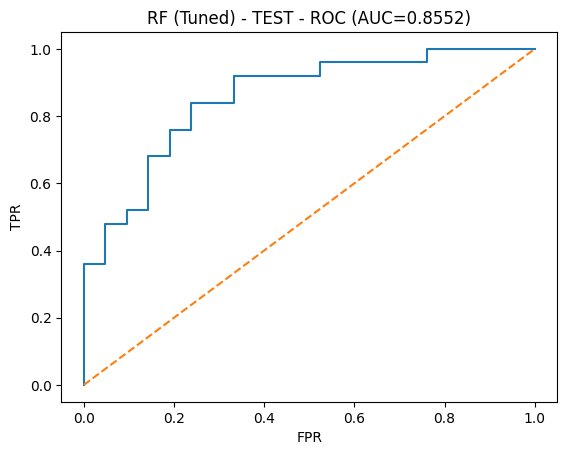

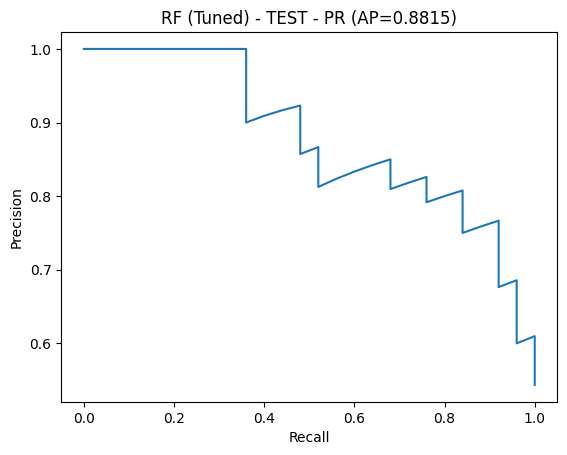

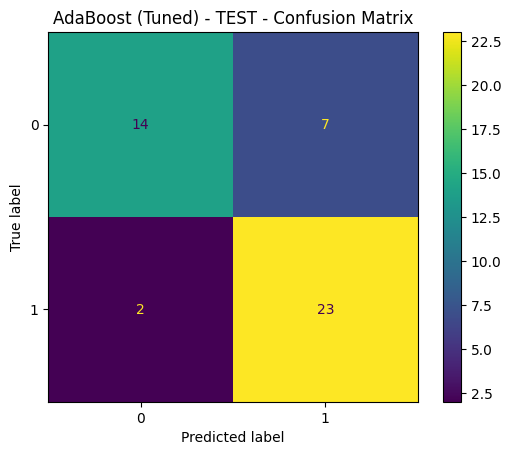

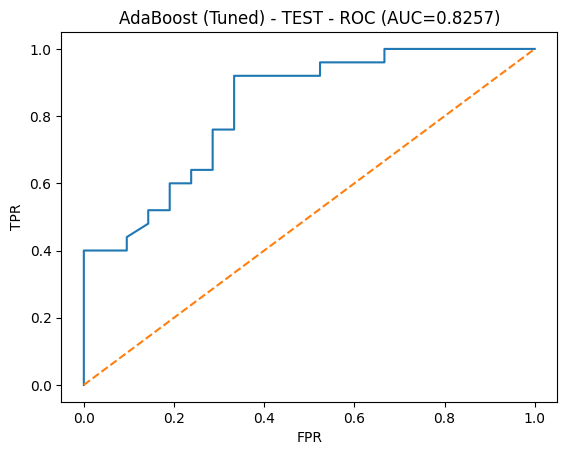

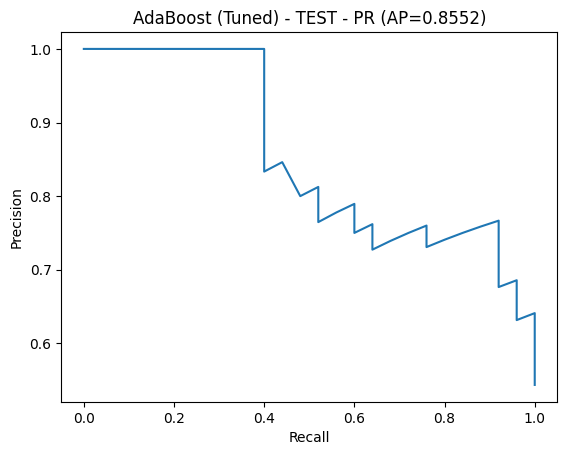

In [22]:
for name, mdl in fitted_tuned.items():
    plot_diagnostics(mdl, X_test, y_test, title=f"{name} - TEST")


#### Learning Curves

C:\Users\user\anaconda3\envs\env\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\user\anaconda3\envs\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\user\anaconda3\envs\env\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\anaconda3\envs\env\Lib\site-packages\sklearn\pipeline.py", line 662, in f

<Figure size 640x480 with 0 Axes>

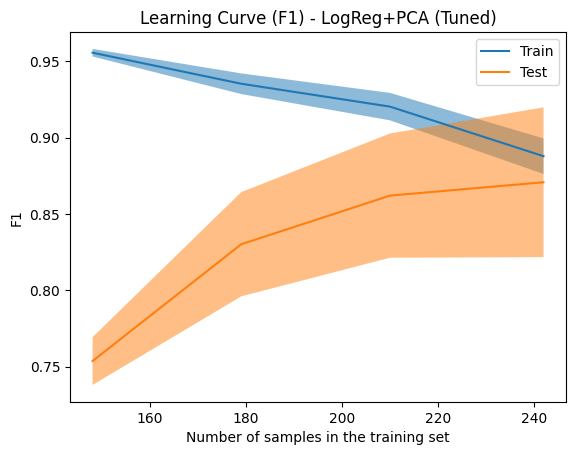

<Figure size 640x480 with 0 Axes>

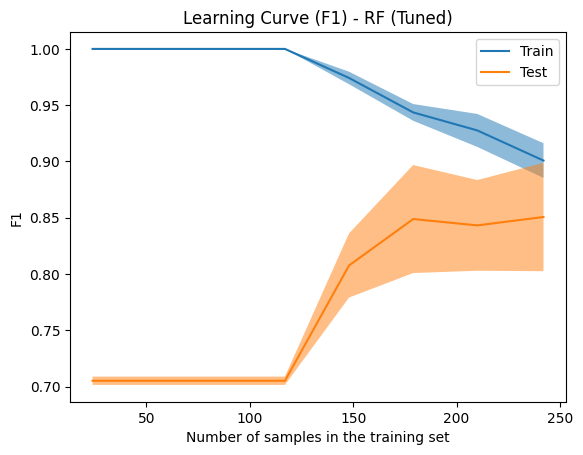

<Figure size 640x480 with 0 Axes>

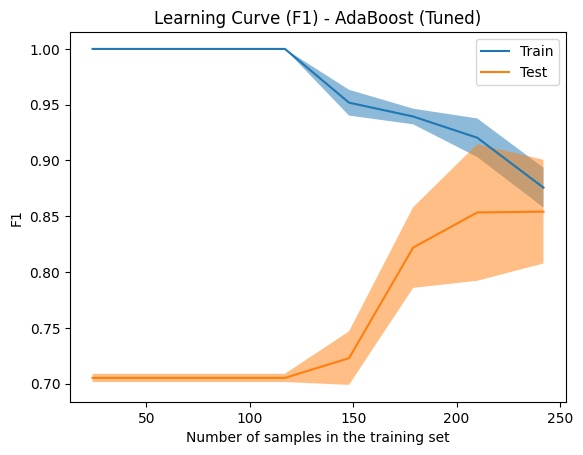

In [23]:
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, mdl in tuned_models.items():
    plt.figure()
    LearningCurveDisplay.from_estimator(
        mdl, X, y,
        cv=cv_lc,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )
    plt.title(f"Learning Curve (F1) - {name}")
    plt.show()


### هزینه محاسباتی

,model,fit_time_mean,fit_time_std,score_time_mean,score_time_std
1,RF (Tuned),7.589088,1.910712,0.454256,0.126074
2,AdaBoost (Tuned),1.025208,0.248621,0.172461,0.043324
0,LogReg+PCA (Tuned),0.109431,0.023654,0.054119,0.015515


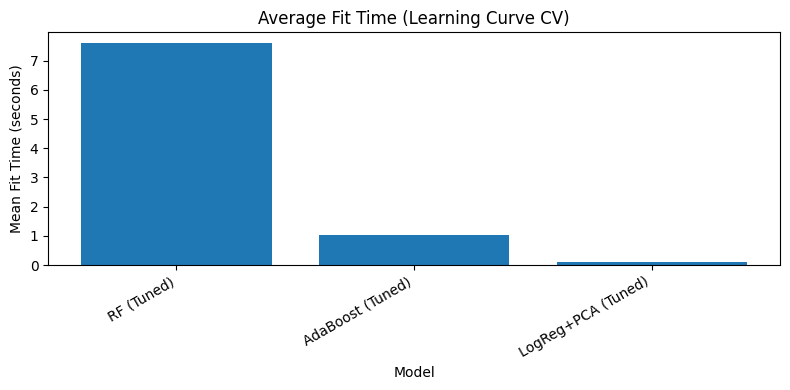

In [24]:
# Computational Cost 
from sklearn.model_selection import learning_curve

cv_time = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fit_time_summary = []

for name, mdl in fitted_tuned.items():
    train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
        mdl,
        X_train, y_train,
        cv=cv_time,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 5),
        return_times=True
    )
    fit_time_summary.append({
        "model": name,
        "fit_time_mean": fit_times.mean(),
        "fit_time_std": fit_times.std(),
        "score_time_mean": score_times.mean(),
        "score_time_std": score_times.std()
    })

time_df = pd.DataFrame(fit_time_summary).sort_values("fit_time_mean", ascending=False)
display(time_df)

plt.figure(figsize=(8, 4))
plt.bar(time_df["model"], time_df["fit_time_mean"])
plt.title("Average Fit Time (Learning Curve CV)")
plt.xlabel("Model")
plt.ylabel("Mean Fit Time (seconds)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


###  Threshold Tuning on Validation (optimize F1) + Evaluate on Test

Best tuned model on VAL by F1: LogReg+PCA (Tuned) | VAL F1: 0.8235294117647058
Best threshold (VAL) for max F1: 0.58
VAL F1: 0.8571428571428571 | VAL Precision: 0.875 | VAL Recall: 0.84


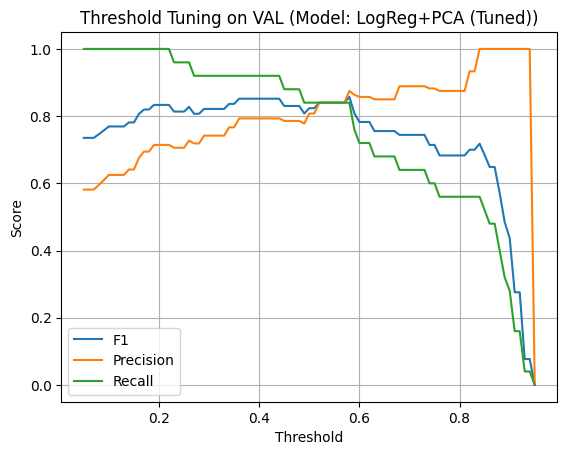

Confusion Matrix on VAL @ best threshold:
 [[17  3]
 [ 4 21]]

TEST Metrics @ tuned threshold
F1: 0.7755102040816326
Precision: 0.7916666666666666
Recall: 0.76
Confusion Matrix (TEST):
 [[16  5]
 [ 6 19]]


In [25]:

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

best_tuned_name = None
best_val_f1 = -1
for name, mdl in fitted_tuned.items():
    m = compute_metrics(mdl, X_val, y_val)
    if m["f1"] > best_val_f1:
        best_val_f1 = m["f1"]
        best_tuned_name = name

best_tuned_model = fitted_tuned[best_tuned_name]
print("Best tuned model on VAL by F1:", best_tuned_name, "| VAL F1:", best_val_f1)

# گرفتن احتمال کلاس مثبت
val_proba = best_tuned_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
f1_list, p_list, r_list = [], [], []

for t in thresholds:
    y_hat = (val_proba >= t).astype(int)
    f1_list.append(f1_score(y_val, y_hat))
    p_list.append(precision_score(y_val, y_hat, zero_division=0))
    r_list.append(recall_score(y_val, y_hat, zero_division=0))

best_idx = int(np.argmax(f1_list))
best_thr = float(thresholds[best_idx])

print("Best threshold (VAL) for max F1:", best_thr)
print("VAL F1:", f1_list[best_idx], "| VAL Precision:", p_list[best_idx], "| VAL Recall:", r_list[best_idx])

# Plot curves
plt.figure()
plt.plot(thresholds, f1_list, label="F1")
plt.plot(thresholds, p_list, label="Precision")
plt.plot(thresholds, r_list, label="Recall")
plt.title(f"Threshold Tuning on VAL (Model: {best_tuned_name})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.show()

# Confusion Matrix on VAL at best threshold
val_pred_best = (val_proba >= best_thr).astype(int)
cm_val = confusion_matrix(y_val, val_pred_best)
print("Confusion Matrix on VAL @ best threshold:\n", cm_val)

# Evaluate on TEST with the tuned threshold
test_proba = best_tuned_model.predict_proba(X_test)[:, 1]
test_pred_best = (test_proba >= best_thr).astype(int)

print("\nTEST Metrics @ tuned threshold")
print("F1:", f1_score(y_test, test_pred_best))
print("Precision:", precision_score(y_test, test_pred_best, zero_division=0))
print("Recall:", recall_score(y_test, test_pred_best, zero_division=0))
print("Confusion Matrix (TEST):\n", confusion_matrix(y_test, test_pred_best))


#### Calibration Curves

<Figure size 640x480 with 0 Axes>

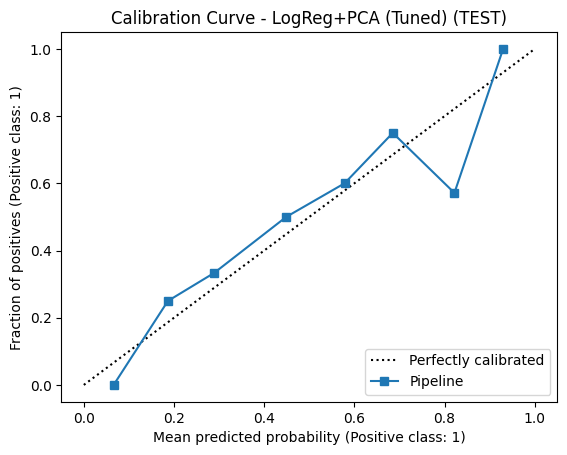

<Figure size 640x480 with 0 Axes>

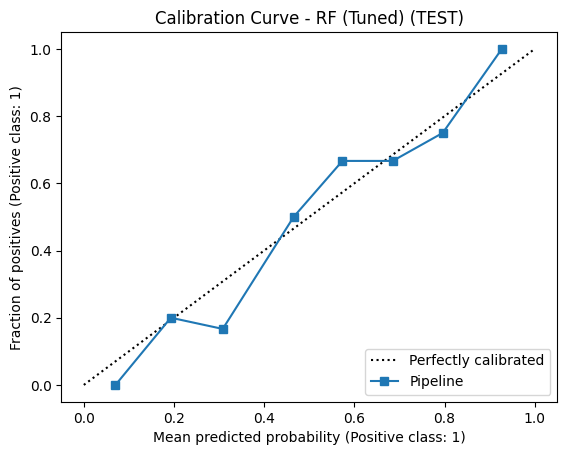

<Figure size 640x480 with 0 Axes>

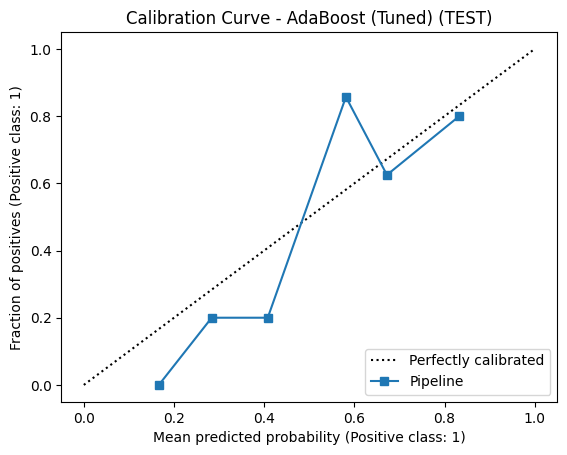

In [26]:
for name, mdl in fitted_tuned.items():
    if hasattr(mdl, "predict_proba"):
        plt.figure()
        CalibrationDisplay.from_estimator(mdl, X_test, y_test, n_bins=8)
        plt.title(f"Calibration Curve - {name} (TEST)")
        plt.show()


#### Permutation Importance

In [27]:
best_tuned_name = None
best_val_f1 = -1

for name, mdl in fitted_tuned.items():
    m = compute_metrics(mdl, X_val, y_val)
    if m["f1"] > best_val_f1:
        best_val_f1 = m["f1"]
        best_tuned_name = name

best_tuned_model = fitted_tuned[best_tuned_name]
print("Best tuned model on VAL by F1:", best_tuned_name, "| VAL F1:", best_val_f1)

perm = permutation_importance(
    best_tuned_model, X_val, y_val,
    scoring="f1",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp_df.head(15)


Best tuned model on VAL by F1: LogReg+PCA (Tuned) | VAL F1: 0.8235294117647058


,feature,importance_mean,importance_std
12,thal,0.036583,0.030261
11,ca,0.034534,0.027029
1,sex,0.023498,0.020549
2,cp,0.019516,0.026473
9,oldpeak,0.012908,0.021169
7,thalach,0.012052,0.029984
8,exang,0.005002,0.021316
3,trestbps,0.004831,0.009336
6,restecg,0.000000,0.000000
0,age,-0.000172,0.010100


### SHAP for models WITHOUT PCA (3 models) 

Models selected for SHAP (No PCA):
 - LogReg (Untuned)
 - RF (Untuned)
 - AdaBoost (Untuned)
 - RF (scaled preprocess) (Untuned)
 - RF (Tuned)
 - AdaBoost (Tuned)


PermutationExplainer explainer: 47it [00:13,  3.42it/s]                        


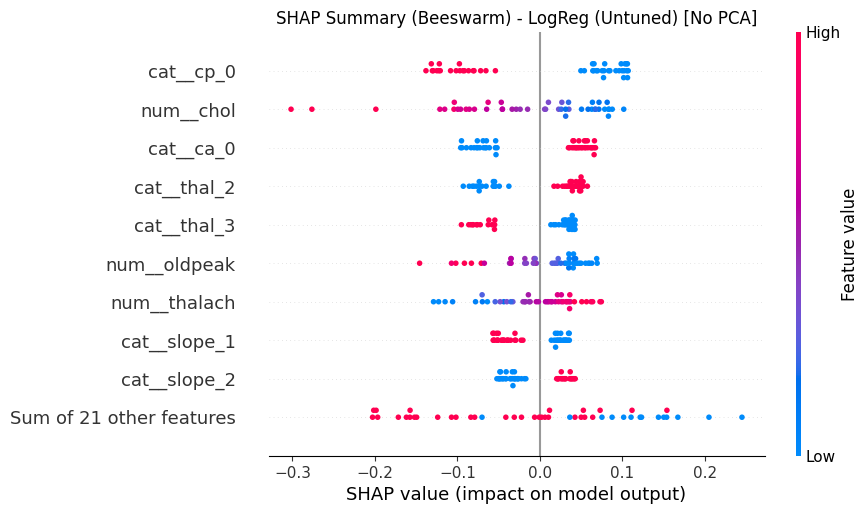

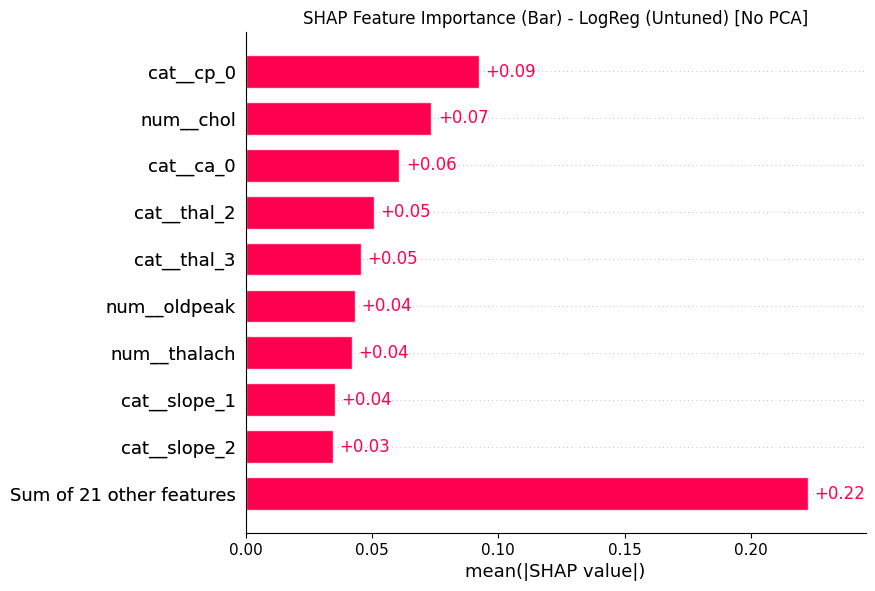

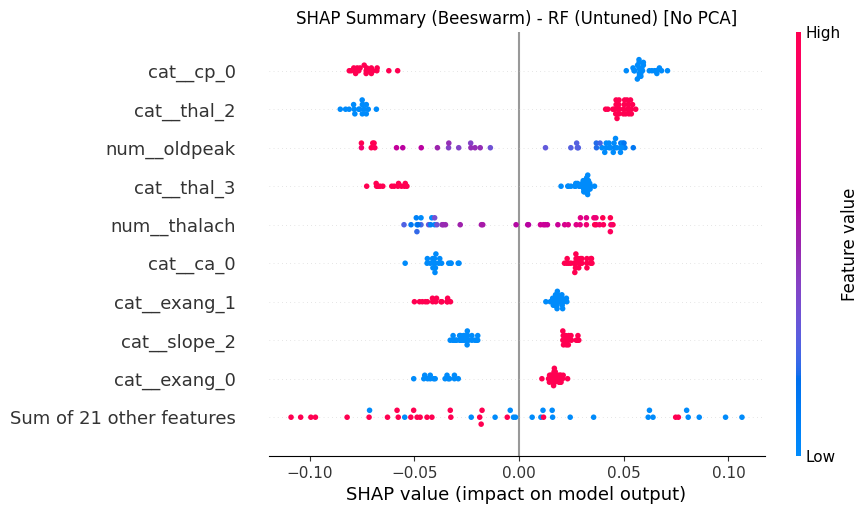

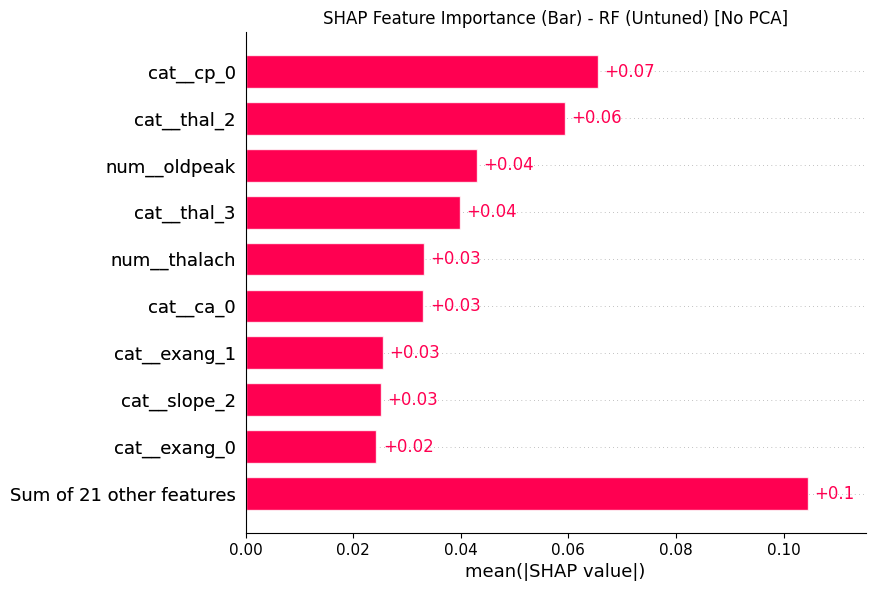

PermutationExplainer explainer: 47it [01:15,  1.89s/it]                        


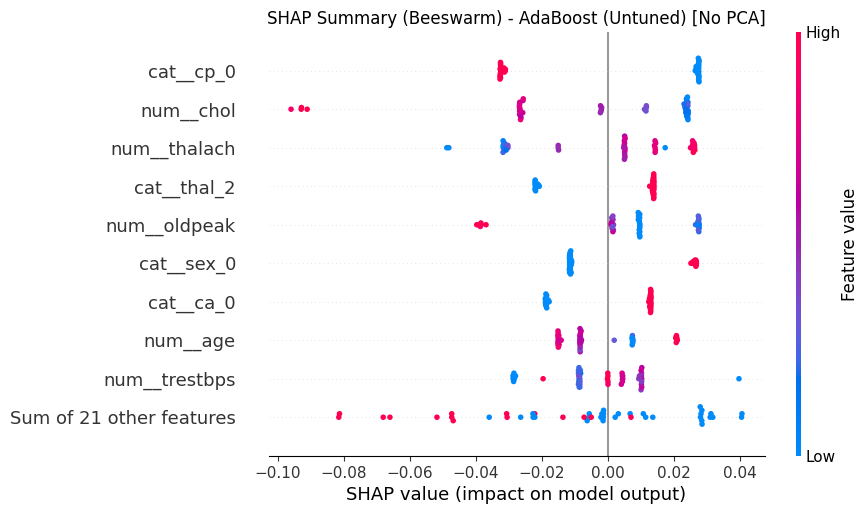

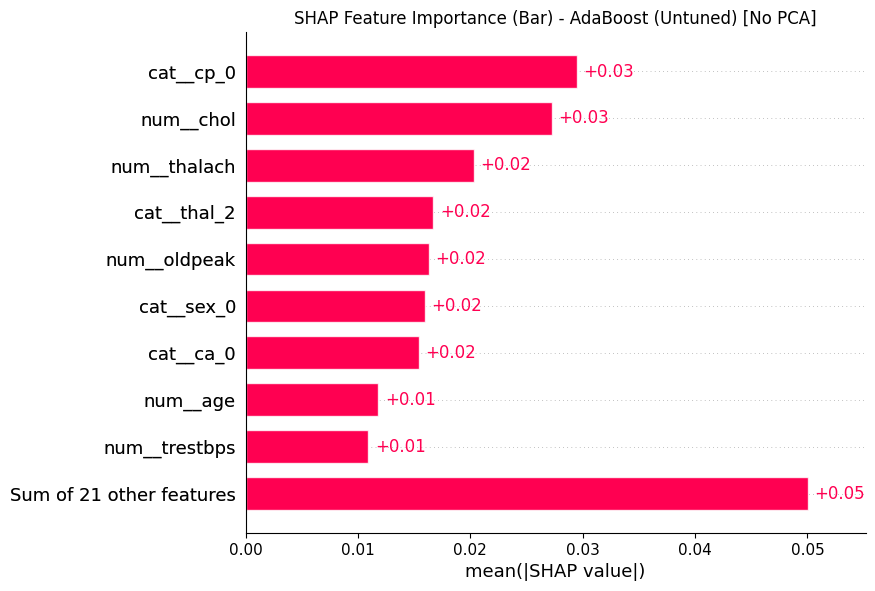

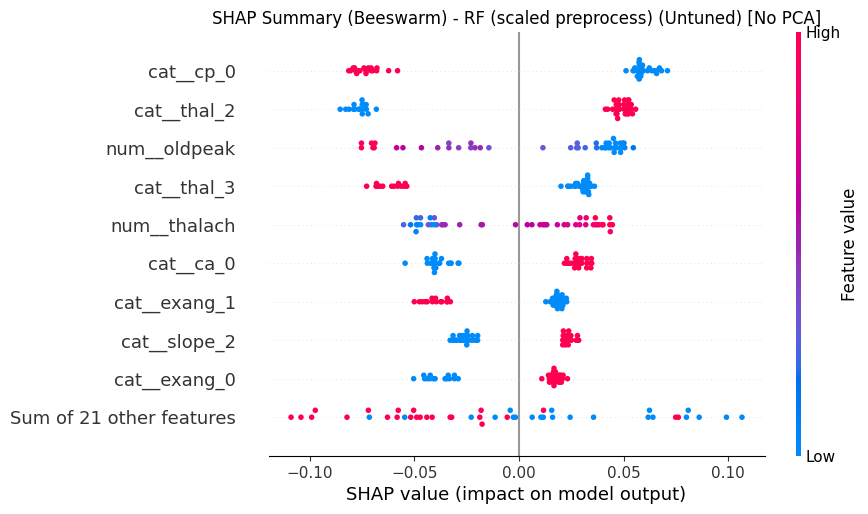

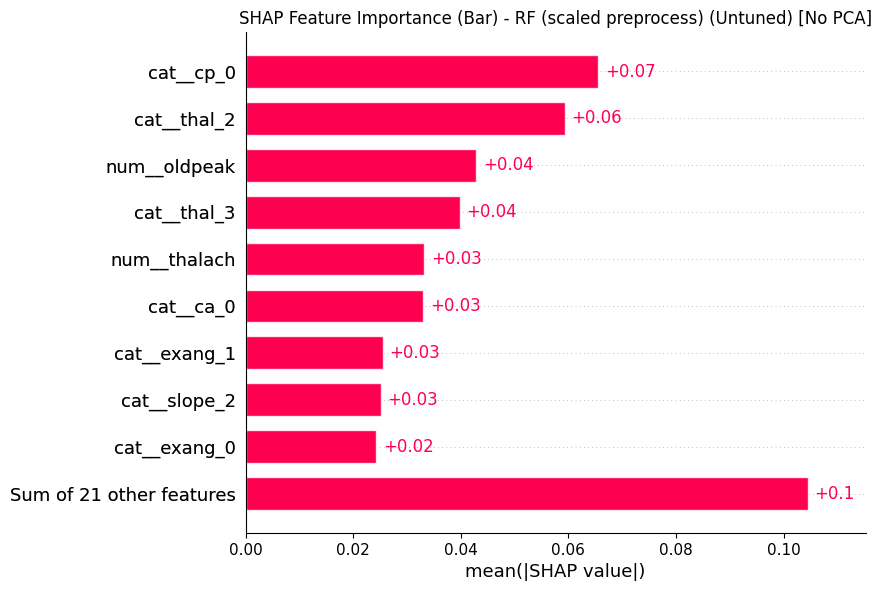

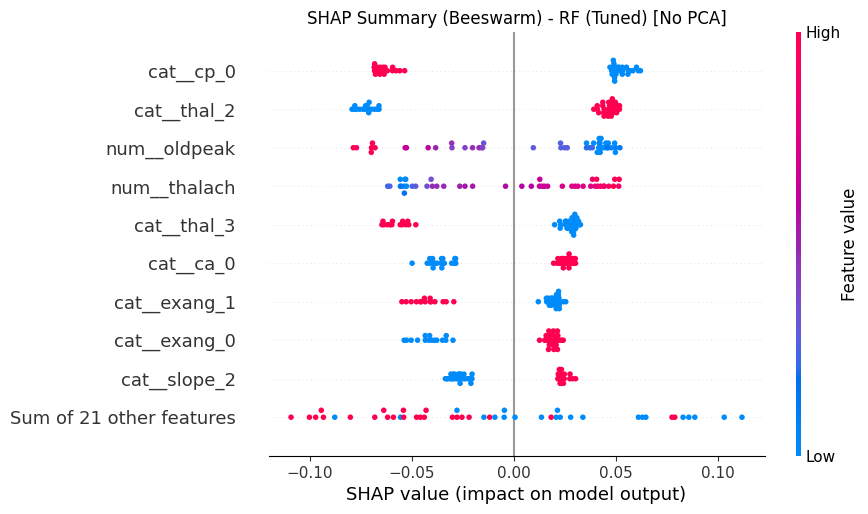

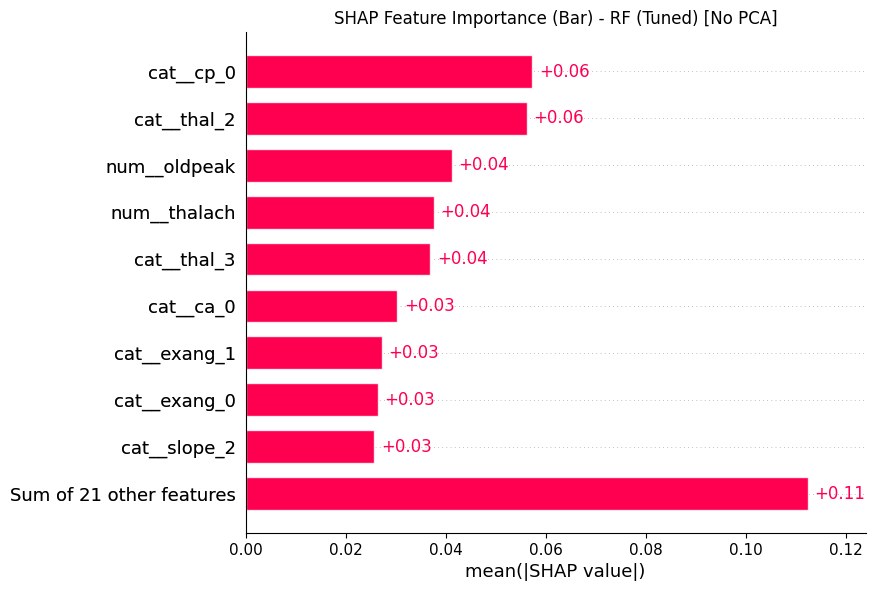

PermutationExplainer explainer: 47it [00:23,  1.14it/s]                        


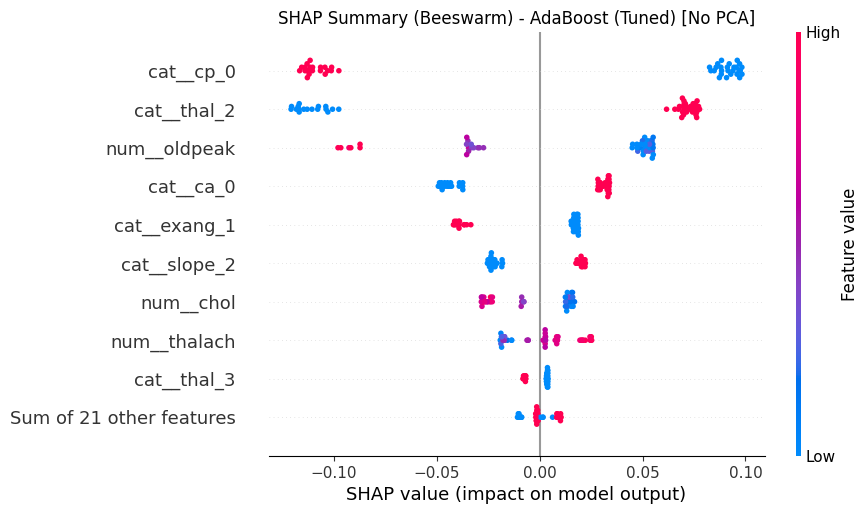

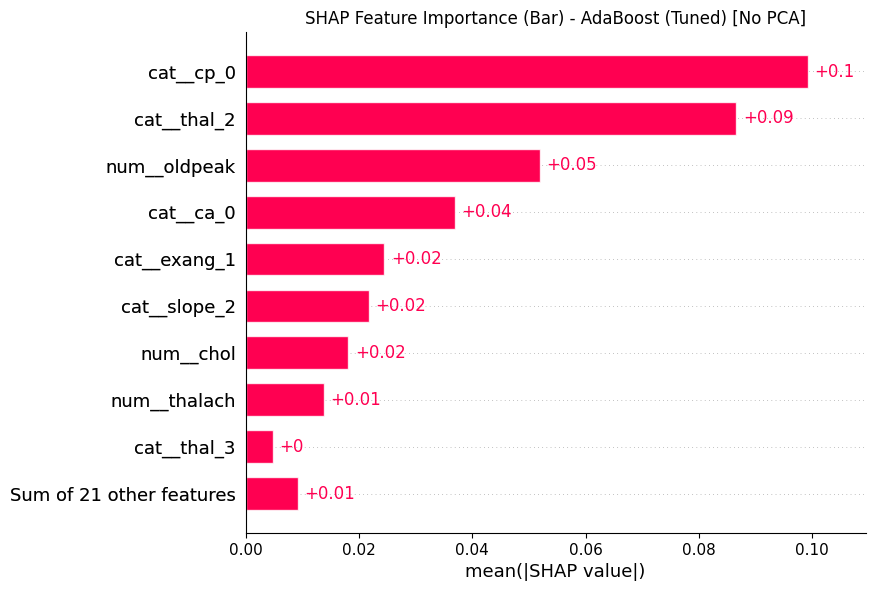

In [28]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier

def _to_dense(X):
    return X.toarray() if sparse.issparse(X) else X

def _get_feat_names(prep, X_transformed):
    if prep is not None and hasattr(prep, "get_feature_names_out"):
        try:
            return prep.get_feature_names_out()
        except Exception:
            pass
    return np.array([f"f{i}" for i in range(X_transformed.shape[1])], dtype=object)

def _pick_positive_class(exp):
    # exp.values shape: (n,p) or (n,p,k)
    if exp.values is not None and exp.values.ndim == 3:
        return exp[..., 1]   # class 1
    return exp

def shap_for_no_pca_pipeline(pipe, X_train, X_test, model_name,
                             bg_size=200, explain_size=200, random_state=42):
    prep = pipe.named_steps.get("prep", None)
    clf  = pipe.named_steps.get("clf", None)
    if clf is None:
        raise ValueError(f"{model_name}: pipeline must have a 'clf' step.")

    # sample
    X_bg = X_train.sample(min(bg_size, len(X_train)), random_state=random_state)
    X_ex = X_test.sample(min(explain_size, len(X_test)), random_state=random_state)

    # transform with preprocessing
    if prep is not None:
        X_bg_t = prep.transform(X_bg)
        X_ex_t = prep.transform(X_ex)
    else:
        X_bg_t = X_bg.values
        X_ex_t = X_ex.values

    feat_names = _get_feat_names(prep, X_bg_t)
    X_bg_t = _to_dense(X_bg_t)
    X_ex_t = _to_dense(X_ex_t)

    # ---- choose explainer ----
    # Fast path for RF: TreeExplainer
    # General path (works for AdaBoost too): use callable predict_proba with unified Explainer
    try:
        if isinstance(clf, RandomForestClassifier):
            # TreeExplainer supports tree models and can explain predict_proba/probability outputs. :contentReference[oaicite:2]{index=2}
            explainer = shap.TreeExplainer(clf, data=X_bg_t, feature_names=feat_names, model_output="probability")
            shap_vals = explainer(X_ex_t)
        else:
            # For models that SHAP can't wrap directly, pass a callable (predict_proba). :contentReference[oaicite:3]{index=3}
            explainer = shap.Explainer(clf.predict_proba, X_bg_t, feature_names=feat_names)
            shap_vals = explainer(X_ex_t)

    except Exception as e:
        # Ultimate fallback: permutation explainer via callable predict_proba
        print(f"[WARN] Falling back to callable Explainer for {model_name} due to: {e}")
        explainer = shap.Explainer(clf.predict_proba, X_bg_t, feature_names=feat_names)
        shap_vals = explainer(X_ex_t)

    shap_pos = _pick_positive_class(shap_vals)

    # ---- plots ----
    plt.figure()
    shap.plots.beeswarm(shap_pos, show=False)
    plt.title(f"SHAP Summary (Beeswarm) - {model_name} [No PCA]")
    plt.show()

    plt.figure()
    shap.plots.bar(shap_pos, show=False)
    plt.title(f"SHAP Feature Importance (Bar) - {model_name} [No PCA]")
    plt.show()


# =========================
# Select NO-PCA models from your notebook objects
# =========================
no_pca_candidates = {}

# untuned
for k in ["LogReg", "RF", "AdaBoost", "RF (scaled preprocess)"]:
    if "fitted_untuned" in globals() and k in fitted_untuned:
        no_pca_candidates[k + " (Untuned)"] = fitted_untuned[k]

# tuned (RF and AdaBoost are no-PCA in your setup; LogReg+PCA excluded)
for k in ["RF (Tuned)", "AdaBoost (Tuned)"]:
    if "fitted_tuned" in globals() and k in fitted_tuned:
        no_pca_candidates[k] = fitted_tuned[k]

print("Models selected for SHAP (No PCA):")
for k in no_pca_candidates:
    print(" -", k)

for name, mdl in no_pca_candidates.items():
    shap_for_no_pca_pipeline(
        mdl, X_train, X_test,
        model_name=name,
        bg_size=200, explain_size=200,
        random_state=RANDOM_STATE
    )


### مقایسه کلی مدل ها

In [29]:

# Tuned models 
models_to_plot = fitted_tuned  # dict: name -> fitted pipeline

# Untuned models
print("Models to plot:", list(models_to_plot.keys()))


Models to plot: ['LogReg+PCA (Tuned)', 'RF (Tuned)', 'AdaBoost (Tuned)']


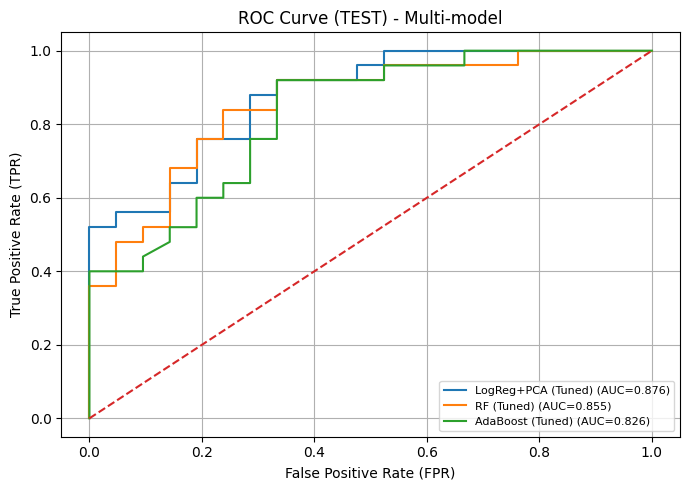

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Multi-model ROC curve


plt.figure(figsize=(7, 5))

for name, mdl in models_to_plot.items():
    # probability scores
    if hasattr(mdl, "predict_proba"):
        scores = mdl.predict_proba(X_test)[:, 1]
    elif hasattr(mdl, "decision_function"):
        scores = mdl.decision_function(X_test)
    else:
        print(f"[SKIP] {name}: no predict_proba/decision_function")
        continue

    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_ = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_:.3f})")

# baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve (TEST) - Multi-model")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


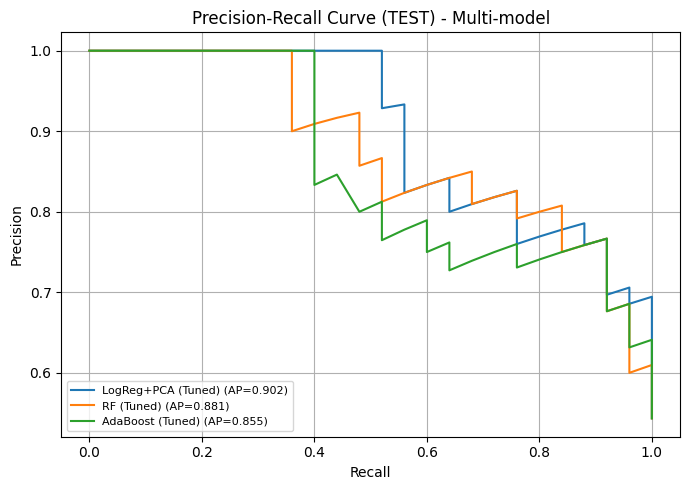

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Multi-model Precision-Recall curve

plt.figure(figsize=(7, 5))

for name, mdl in models_to_plot.items():
    if hasattr(mdl, "predict_proba"):
        scores = mdl.predict_proba(X_test)[:, 1]
    elif hasattr(mdl, "decision_function"):
        scores = mdl.decision_function(X_test)
    else:
        print(f"[SKIP] {name}: no predict_proba/decision_function")
        continue

    prec, rec, _ = precision_recall_curve(y_test, scores)
    ap = average_precision_score(y_test, scores)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision-Recall Curve (TEST) - Multi-model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


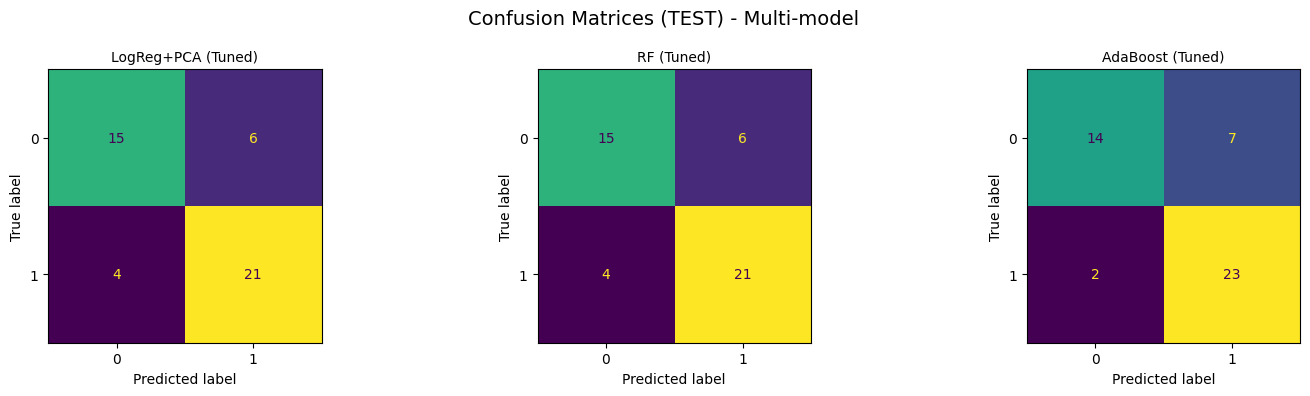

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Multi-model Confusion Matrices (grid)


names = list(models_to_plot.keys())
n = len(names)

cols = 3  
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, names):
    mdl = models_to_plot[name]
    y_pred = mdl.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=10)


for j in range(len(names), len(axes)):
    axes[j].axis("off")

plt.suptitle("Confusion Matrices (TEST) - Multi-model", fontsize=14)
plt.tight_layout()
plt.show()


In [33]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)


# Summary table (TEST) for slide 29


rows = []

for name, mdl in models_to_plot.items():
    y_pred = mdl.predict(X_test)

    # scores for AUC/AP
    scores = None
    if hasattr(mdl, "predict_proba"):
        scores = mdl.predict_proba(X_test)[:, 1]
    elif hasattr(mdl, "decision_function"):
        scores = mdl.decision_function(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

    if scores is not None:
        row["roc_auc"] = roc_auc_score(y_test, scores)
        row["ap"] = average_precision_score(y_test, scores)
    else:
        row["roc_auc"] = np.nan
        row["ap"] = np.nan

    rows.append(row)

summary_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(summary_df)


,model,accuracy,precision,recall,f1,TN,FP,FN,TP,roc_auc,ap
2,AdaBoost (Tuned),0.804348,0.766667,0.92,0.836364,14,7,2,23,0.825714,0.855188
0,LogReg+PCA (Tuned),0.782609,0.777778,0.84,0.807692,15,6,4,21,0.876190,0.902491
1,RF (Tuned),0.782609,0.777778,0.84,0.807692,15,6,4,21,0.855238,0.881488


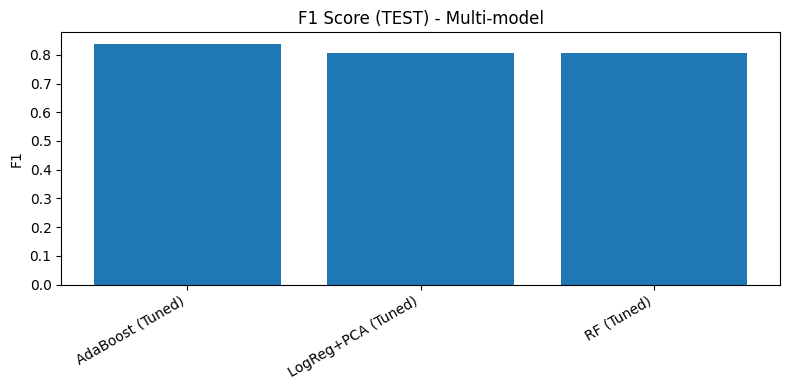

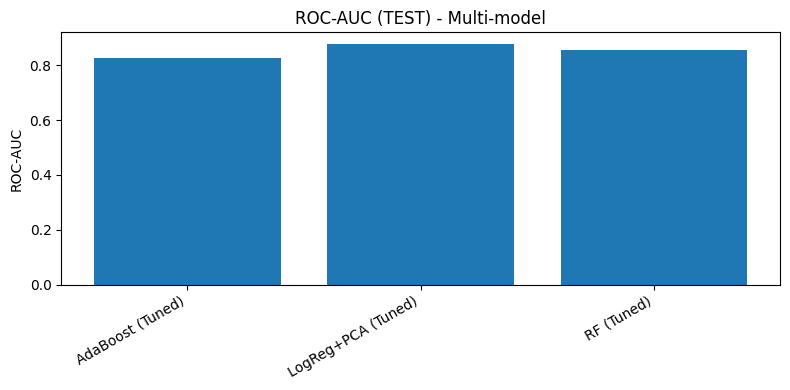

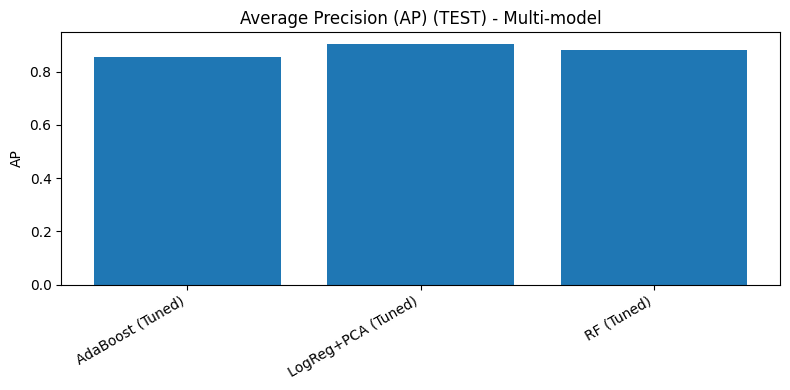

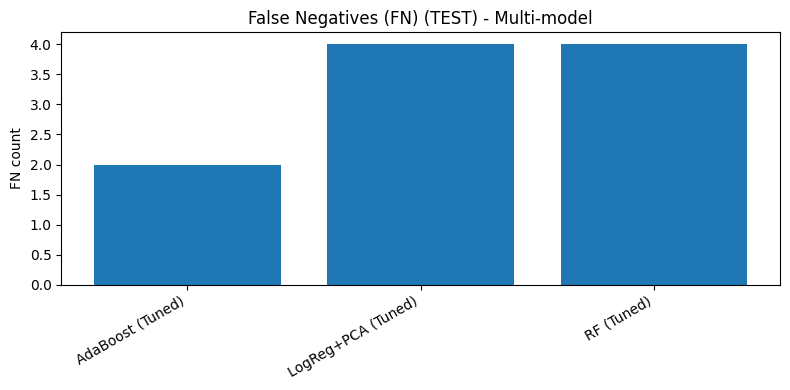

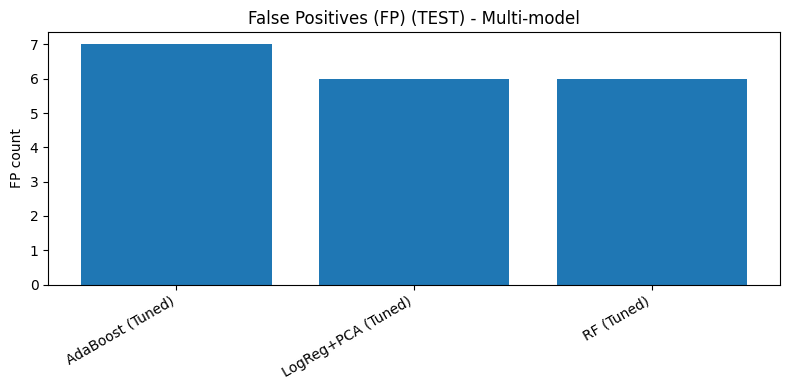

In [34]:
import matplotlib.pyplot as plt

# Bar plots for key metrics (TEST)

plot_df = summary_df.copy()

# 1) F1
plt.figure(figsize=(8, 4))
plt.bar(plot_df["model"], plot_df["f1"])
plt.title("F1 Score (TEST) - Multi-model")
plt.ylabel("F1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 2) ROC-AUC
plt.figure(figsize=(8, 4))
plt.bar(plot_df["model"], plot_df["roc_auc"])
plt.title("ROC-AUC (TEST) - Multi-model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 3) Average Precision (AP)
plt.figure(figsize=(8, 4))
plt.bar(plot_df["model"], plot_df["ap"])
plt.title("Average Precision (AP) (TEST) - Multi-model")
plt.ylabel("AP")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 4) FN and FP (important in medical setting)
plt.figure(figsize=(8, 4))
plt.bar(plot_df["model"], plot_df["FN"])
plt.title("False Negatives (FN) (TEST) - Multi-model")
plt.ylabel("FN count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(plot_df["model"], plot_df["FP"])
plt.title("False Positives (FP) (TEST) - Multi-model")
plt.ylabel("FP count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
